In [1]:
from backend.utils.gmsh_function import *
from backend.src.radiation_algorithm.radiation_algorithm import *
from backend.utils.file_path import *
from backend.rwg.rwg6 import plot_surface_current_distribution

In [2]:
name = "strip_gap_radiation"
path = setup_save_file_paths(name)

In [3]:
mm = 1e-3
width = 20  * mm
length = 2000 * mm
# feed_point = np.array([0, length / 5, 0])
feed_point = np.array([0, 0, 0])

In [4]:
light_speed = 3e8

frequency = 75e6
wavelength = light_speed / frequency
print(f"wavelength = {wavelength} Meter")

wavelength = 4.0 Meter


In [5]:
initial_mesh_size = 0.05
# initial_mesh_size = wavelength / 30
print(f"initial_mesh_size = {initial_mesh_size}")

gmsh.initialize()
model_name  = "strip_antenna"

print(f"Longueur: {width} m, Hauteur: {length} m")

# Model creation
gmsh.model.add(model_name)
setup_performance_config()

strip_antenna = gmsh.model.occ.addRectangle(-width / 2, -length / 2, 0, width, length)

# synchronize after embedding
gmsh.model.occ.synchronize()

generate_and_save_mesh(path, initial_mesh_size)

# gmsh.fltk.run()

gmsh.finalize()

initial_mesh_size = 0.05
Longueur: 0.02 m, Hauteur: 2.0 m
[PERFORMANCE] Gmsh configured to utilize 16 threads.
Geometry file saved in data/gmsh_files/strip_gap_radiation.brep successfully
--- Starting Mesh Optimization (Dim: 2) ---
--- Optimization Complete ---
Mesh file saved in data/gmsh_files/strip_gap_radiation.msh successfully


if new_feed: matrice_z, voltage, current, surface_current_density = radiation_algorithm(path.mat, frequency, feed_point, voltage_amplitude=1, port_type=0)
else: pass

In [6]:
_ = radiation_algorithm(path, frequency, feed_point, excitation_unit_vector='y', gap_width=1.1*initial_mesh_size)

MODE SELECTED: radiation


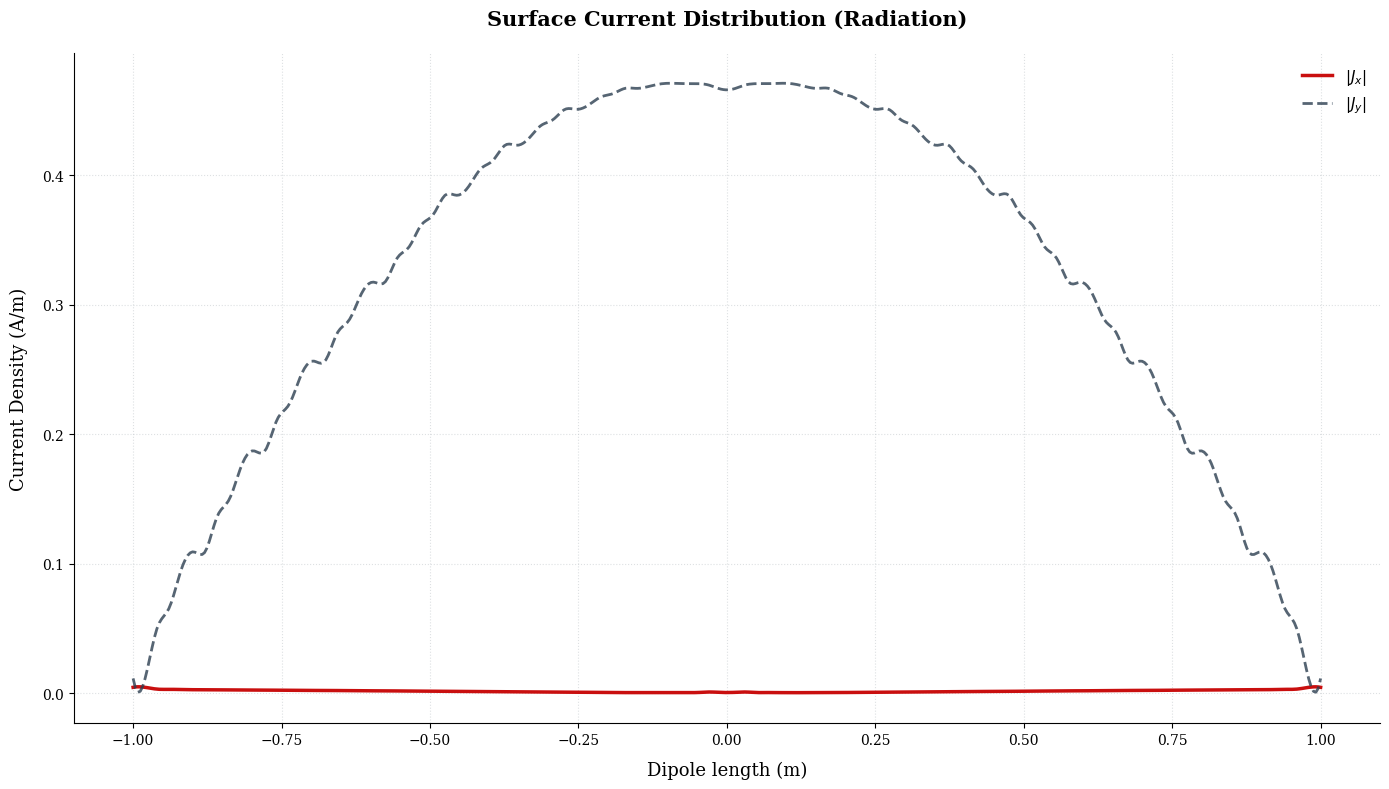

In [7]:
plot_surface_current_distribution(path, mode='radiation')